# STAT 175 Final Project: GraphSAGE Baseline on Twitch Gamer Networks

This notebook implements the **GraphSAGE baseline** for the STAT 175 final project.

Main things this notebook does:

1. Loads the PyTorch Geometric Twitch datasets: `DE`, `EN`, `ES`, `FR`, `PT`, `RU`.
2. Creates consistent stratified train/validation/test node splits.
3. Trains a full-batch GraphSAGE model for binary node classification.
4. Reports accuracy, F1, macro F1, ROC-AUC, and loss.
5. Repeats the experiment across random seeds.
6. Saves the raw results, summary table, graph statistics, training histories, and plots.
7. Optionally runs the layer-depth ablation for GraphSAGE.

Recommended workflow:

- First run this notebook in **quick mode** to make sure everything works.
- Then switch `RUN_MODE = "full"` in the configuration cell.
- If time allows, turn on the layer ablation.

## 0. Colab setup notes

Before running:

1. In Colab, go to **Runtime → Change runtime type**.
2. Set **Hardware accelerator** to **T4 GPU** if available.
3. Run the installation cell below.
4. If PyTorch Geometric installation fails, restart the runtime and rerun the first few cells.

This notebook is self-contained, so it does not require any separate utility files.

In [40]:
# Check Python and PyTorch environment.
import sys, os, platform
print("Python:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    print("Torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
except Exception as e:
    print("Torch import failed:", repr(e))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8


In [41]:
# Install PyTorch Geometric.
# In current Colab environments, this usually works directly.
# If this cell asks you to restart the runtime, restart and then rerun the imports below.

!pip -q install torch_geometric

# Optional: print version after install.
import torch
import torch_geometric
print("Torch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cu128
PyG: 2.7.0
CUDA available: True


In [42]:
# Fallback install cell.
# Only run this if the previous install/import cell fails with a PyG extension error.
# It installs optional PyG acceleration libraries matching your current Torch/CUDA version.

import torch, os

torch_version = torch.__version__.split("+")[0]
cuda_version = torch.version.cuda
if cuda_version is None:
    cuda_tag = "cpu"
else:
    cuda_tag = "cu" + cuda_version.replace(".", "")

wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_tag}.html"
print("Torch version:", torch_version)
print("CUDA tag:", cuda_tag)
print("Using wheel URL:", wheel_url)

!pip -q install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f {wheel_url}
!pip -q install torch_geometric

import torch_geometric
print("PyG:", torch_geometric.__version__)

Torch version: 2.10.0
CUDA tag: cu128
Using wheel URL: https://data.pyg.org/whl/torch-2.10.0+cu128.html
PyG: 2.7.0


## 1. Imports and configuration

Start in `RUN_MODE = "quick"`.

Once the notebook runs successfully, change to `RUN_MODE = "full"` and rerun from the configuration cell onward.

In [43]:
import os
import random
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from torch_geometric.datasets import Twitch
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import degree, to_undirected

# -------------------------
# Main configuration
# -------------------------

RUN_MODE = "full"   # "quick" first, then change to "full"

if RUN_MODE == "quick":
    # Quick sanity run: one small-ish graph and one seed.
    LANGUAGES = ["PT"]
    SEEDS = [0]
    MAX_EPOCHS = 50
    PATIENCE = 10
else:
    # Full project run.
    # CHANGED: 10 seeds -> 5 seeds to match the MLP/GCN/GAT notebooks.
    # Std deviations across models will now be computed on the same number of samples,
    # so the cross-model error bars are directly comparable.
    LANGUAGES = ["DE", "EN", "ES", "FR", "PT", "RU"]
    SEEDS = [0, 1, 2, 3, 4]
    MAX_EPOCHS = 300
    PATIENCE = 40

# Model/training defaults.
HIDDEN_CHANNELS = 64
NUM_LAYERS = 2
DROPOUT = 0.5
LEARNING_RATE = 0.005
WEIGHT_DECAY = 5e-4

TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

# CHANGED: Selection metric is now positive-class F1, matching MLP/GCN/GAT.
# All four notebooks now train and select models on the same metric.
# Both f1 and macro_f1 are still logged in the per-epoch history and final results,
# so the headline table can be regenerated under either choice without retraining.
SELECTION_METRIC = "macro_f1"

# Optional ablation. Leave False until the baseline works.
RUN_LAYER_ABLATION = True
ABLATION_LAYERS = [1, 2, 3, 4]
ABLATION_SEEDS = [0, 1, 2] if RUN_MODE == "full" else [0]

# Output directory. In Colab, this saves under /content by default.
OUTPUT_DIR = Path("/content/stat175_graphsage_outputs")
(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "histories").mkdir(parents=True, exist_ok=True)
# NEW: dedicated subfolder for split JSONs, matching the MLP/GCN/GAT layout.
(OUTPUT_DIR / "splits").mkdir(parents=True, exist_ok=True)

DATA_ROOT = "/content/data/Twitch"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Run mode:", RUN_MODE)
print("Languages:", LANGUAGES)
print("Seeds:", SEEDS)
print("Selection metric:", SELECTION_METRIC)
print("Device:", device)
print("Output directory:", OUTPUT_DIR)


Run mode: full
Languages: ['DE', 'EN', 'ES', 'FR', 'PT', 'RU']
Seeds: [0, 1, 2, 3, 4]
Selection metric: macro_f1
Device: cuda
Output directory: /content/stat175_graphsage_outputs


In [33]:
# Optional Google Drive mounting.
# Run this only if your team wants outputs saved directly to Google Drive.
# After mounting, change OUTPUT_DIR to the desired shared folder path.

#from google.colab import drive
#drive.mount('/content/drive')
#OUTPUT_DIR = Path("/content/drive/MyDrive/STAT175_group_project/graphsage_outputs")
#(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
#(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
#(OUTPUT_DIR / "histories").mkdir(parents=True, exist_ok=True)
#print("Output directory changed to:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory changed to: /content/drive/MyDrive/STAT175_group_project/graphsage_outputs


## 2. Helper functions

These functions handle reproducibility, dataset loading, graph statistics, train/validation/test masks, metrics, and early stopping.

In [44]:
def set_seed(seed: int) -> None:
    """Set as many random seeds as practical for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic mode can slow things down, but helps make runs more reproducible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


import json
import urllib.request
from torch_geometric.data import Data

BASE_RAW_URL = "https://raw.githubusercontent.com/CUAI/Non-Homophily-Large-Scale/master/data/twitch"

RAW_DOMAIN_MAP = {
    "DE": "DE",
    "EN": "ENGB",
    "ES": "ES",
    "FR": "FR",
    "PT": "PTBR",
    "RU": "RU",
}

def download_file_if_needed(url, local_path):
    """
    Download a file unless it already exists locally.
    """
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if local_path.exists():
        return local_path

    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, local_path)
    return local_path


def load_twitch_graph(language: str):
    """
    Load one Twitch graph from the public raw GitHub mirror used in Al's notebook.

    This avoids the broken PyG graphmining.ai download URL.
    """
    raw_domain = RAW_DOMAIN_MAP[language]

    local_dir = Path(DATA_ROOT) / "raw_github" / raw_domain
    edges_path = local_dir / f"musae_{raw_domain}_edges.csv"
    features_path = local_dir / f"musae_{raw_domain}_features.json"
    target_path = local_dir / f"musae_{raw_domain}_target.csv"

    edges_url = f"{BASE_RAW_URL}/{raw_domain}/musae_{raw_domain}_edges.csv"
    features_url = f"{BASE_RAW_URL}/{raw_domain}/musae_{raw_domain}_features.json"
    target_url = f"{BASE_RAW_URL}/{raw_domain}/musae_{raw_domain}_target.csv"

    print(f"Loading Twitch dataset: notebook={language}, raw_domain={raw_domain}")

    download_file_if_needed(edges_url, edges_path)
    download_file_if_needed(features_url, features_path)
    download_file_if_needed(target_url, target_path)

    edges_df = pd.read_csv(edges_path)
    target_df = pd.read_csv(target_path)

    with open(features_path, "r") as f:
        features_dict = json.load(f)

    # Robustly use the first two columns as edge endpoints.
    edge_cols = list(edges_df.columns[:2])
    edge_index = torch.tensor(
        edges_df[edge_cols].values.T,
        dtype=torch.long
    )

    # Node ids are stored in the target file as new_id.
    num_nodes = int(target_df["new_id"].max()) + 1

    # Labels: mature content indicator.
    y = torch.zeros(num_nodes, dtype=torch.long)
    for _, row in target_df.iterrows():
        node_id = int(row["new_id"])
        mature_value = row["mature"]

        if isinstance(mature_value, str):
            label = 1 if mature_value.lower() == "true" else 0
        else:
            label = int(bool(mature_value))

        y[node_id] = label

    # Features are stored as a JSON dictionary: node id -> list of feature ids.
    parsed_features = {}
    max_feature_id = -1

    for node_id_str, feature_list in features_dict.items():
        node_id = int(node_id_str)
        feature_list = [int(v) for v in feature_list]
        parsed_features[node_id] = feature_list

        if len(feature_list) > 0:
            max_feature_id = max(max_feature_id, max(feature_list))

    num_features = max_feature_id + 1
    x = torch.zeros((num_nodes, num_features), dtype=torch.float)

    for node_id, feature_list in parsed_features.items():
        if node_id < num_nodes and len(feature_list) > 0:
            x[node_id, feature_list] = 1.0

    data = Data(x=x, edge_index=edge_index, y=y)

    # Return a placeholder dataset name plus the PyG Data object,
    # so the rest of the notebook still works unchanged.
    return f"raw_github_{raw_domain}", data


# NEW: index-based split helper that matches MLP/GCN/GAT's `make_stratified_splits`
# function exactly. We call this internally and then convert to masks for SAGE.
# The advantage: we now save the same index lists those notebooks save, so the
# split JSONs can be diffed across notebooks for verification.
def make_stratified_splits(
    y: np.ndarray,
    seed: int,
    train_ratio: float = 0.60,
    val_ratio: float = 0.20,
    test_ratio: float = 0.20,
):
    """
    Stratified train/val/test split returning numpy index arrays.
    Identical logic to MLP/GCN/GAT notebooks.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8

    indices = np.arange(len(y))

    train_idx, temp_idx = train_test_split(
        indices,
        train_size=train_ratio,
        random_state=seed,
        stratify=y,
    )
    relative_val_ratio = val_ratio / (1.0 - train_ratio)
    val_idx, test_idx = train_test_split(
        temp_idx,
        train_size=relative_val_ratio,
        random_state=seed,
        stratify=y[temp_idx],
    )

    return {
        "train": np.sort(train_idx),
        "val": np.sort(val_idx),
        "test": np.sort(test_idx),
    }


def make_stratified_masks(y, seed: int, train_ratio=0.60, val_ratio=0.20):
    """
    Create stratified train/validation/test masks.

    CHANGED: now delegates to make_stratified_splits for consistency with
    MLP/GCN/GAT, then converts to boolean masks. Functional behavior is
    unchanged because both implementations call sklearn train_test_split
    with the same random_state.
    """
    y_np = y.cpu().numpy() if hasattr(y, "cpu") else np.asarray(y)

    splits = make_stratified_splits(
        y=y_np,
        seed=seed,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        test_ratio=1.0 - train_ratio - val_ratio,
    )

    n = len(y_np)
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)

    train_mask[splits["train"]] = True
    val_mask[splits["val"]] = True
    test_mask[splits["test"]] = True

    return train_mask, val_mask, test_mask


# NEW: helper to write a split to JSON in exactly the format MLP/GCN/GAT use.
# This is what enables the cross-notebook split-consistency check later.
def save_split_json(splits: dict, path) -> None:
    """Save a split dict {train, val, test} of numpy arrays to JSON."""
    payload = {k: [int(i) for i in v] for k, v in splits.items()}
    with open(path, "w") as f:
        json.dump(payload, f)


def binary_class_balance(y):
    """Return the share of nodes in class 1."""
    y_np = y.cpu().numpy()
    return float(np.mean(y_np == 1))


def label_homophily(data):
    """
    Fraction of edges whose endpoints have the same label.
    This uses the directed edge_index as stored. If edges appear twice, the fraction is unaffected.
    """
    src, dst = data.edge_index
    same = (data.y[src] == data.y[dst]).float()
    return float(same.mean().item())


def degree_gini(degrees):
    """Gini coefficient for degree inequality."""
    x = degrees.detach().cpu().numpy().astype(float)
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return float((n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n)


def compute_basic_graph_stats(language: str, data):
    """Compute fast graph statistics useful for the project write-up."""
    num_nodes = data.num_nodes
    num_edges = data.edge_index.size(1)
    num_features = data.num_node_features
    num_classes = int(data.y.max().item() + 1)

    # Use total degree on an undirected version for descriptive statistics.
    undirected_edge_index = to_undirected(data.edge_index, num_nodes=num_nodes)
    deg = degree(undirected_edge_index[0], num_nodes=num_nodes)

    stats = {
        "language": language,
        "num_nodes": int(num_nodes),
        "num_edges_directed_stored": int(num_edges),
        "num_edges_undirected_counted": int(undirected_edge_index.size(1) // 2),
        "num_features": int(num_features),
        "num_classes": int(num_classes),
        "avg_degree_undirected": float(deg.mean().item()),
        "degree_std_undirected": float(deg.std().item()),
        "max_degree_undirected": float(deg.max().item()),
        "degree_cv_undirected": float((deg.std() / (deg.mean() + 1e-12)).item()),
        "degree_gini_undirected": degree_gini(deg),
        "class_1_share": binary_class_balance(data.y),
        "label_homophily_directed_edges": label_homophily(data),
    }
    return stats


@torch.no_grad()
def evaluate_model(model, data, mask):
    """Evaluate model on a particular split mask."""
    model.eval()
    logits = model(data.x, data.edge_index)
    loss = F.cross_entropy(logits[mask], data.y[mask]).item()

    probs = torch.softmax(logits[mask], dim=1)[:, 1].detach().cpu().numpy()
    pred = logits[mask].argmax(dim=1).detach().cpu().numpy()
    y_true = data.y[mask].detach().cpu().numpy()

    acc = accuracy_score(y_true, pred)
    f1 = f1_score(y_true, pred, zero_division=0)
    macro_f1 = f1_score(y_true, pred, average="macro", zero_division=0)

    # ROC-AUC requires both classes to appear in the evaluated split.
    try:
        roc_auc = roc_auc_score(y_true, probs)
    except ValueError:
        roc_auc = np.nan

    return {
        "loss": float(loss),
        "accuracy": float(acc),
        "f1": float(f1),
        "macro_f1": float(macro_f1),
        "roc_auc": float(roc_auc) if not np.isnan(roc_auc) else np.nan,
    }


# NEW: parameter-count helper, used to verify the "similar parameter complexity"
# claim in our presentation/draft against the other models.
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 3. Load the Twitch graphs and save basic dataset statistics

This gives us the dataset summary table needed for the report.

In [45]:
graph_stats = []
loaded_graphs = {}

# NEW: also save split JSONs (one per language x seed) so the splits can be
# diffed against MLP/GCN/GAT. We do this here while the data is in memory.
for language in LANGUAGES:
    print(f"Loading Twitch graph: {language}")
    dataset, data = load_twitch_graph(language)
    loaded_graphs[language] = data

    stats = compute_basic_graph_stats(language, data)
    graph_stats.append(stats)
    print(stats)

    # Save splits for every seed we plan to use.
    y_np = data.y.cpu().numpy()
    for seed in SEEDS:
        splits = make_stratified_splits(
            y=y_np,
            seed=seed,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO,
        )
        split_path = OUTPUT_DIR / "splits" / f"{language}_seed{seed}_splits.json"
        save_split_json(splits, split_path)

graph_stats_df = pd.DataFrame(graph_stats)
display(graph_stats_df)

stats_path = OUTPUT_DIR / "metrics" / "graphsage_dataset_stats.csv"
graph_stats_df.to_csv(stats_path, index=False)
print("Saved graph stats to:", stats_path)
print(f"Saved {len(LANGUAGES) * len(SEEDS)} split JSONs to:", OUTPUT_DIR / "splits")


Loading Twitch graph: DE
Loading Twitch dataset: notebook=DE, raw_domain=DE
{'language': 'DE', 'num_nodes': 9498, 'num_edges_directed_stored': 153138, 'num_edges_undirected_counted': 153138, 'num_features': 3170, 'num_classes': 2, 'avg_degree_undirected': 32.246368408203125, 'degree_std_undirected': 84.80200958251953, 'max_degree_undirected': 4259.0, 'degree_cv_undirected': 2.6298158168792725, 'degree_gini_undirected': 0.630374519154879, 'class_1_share': 0.6045483259633607, 'label_homophily_directed_edges': 0.6322336792945862}
Loading Twitch graph: EN
Loading Twitch dataset: notebook=EN, raw_domain=ENGB
{'language': 'EN', 'num_nodes': 7126, 'num_edges_directed_stored': 35324, 'num_edges_undirected_counted': 35324, 'num_features': 3170, 'num_classes': 2, 'avg_degree_undirected': 9.914116859436035, 'degree_std_undirected': 22.190263748168945, 'max_degree_undirected': 720.0, 'degree_cv_undirected': 2.2382490634918213, 'degree_gini_undirected': 0.6105759178344167, 'class_1_share': 0.545607

,language,num_nodes,num_edges_directed_stored,num_edges_undirected_counted,num_features,num_classes,avg_degree_undirected,degree_std_undirected,max_degree_undirected,degree_cv_undirected,degree_gini_undirected,class_1_share,label_homophily_directed_edges
0,DE,9498,153138,153138,3170,2,32.246368,84.802010,4259.0,2.629816,0.630375,0.604548,0.632234
1,EN,7126,35324,35324,3170,2,9.914117,22.190264,720.0,2.238249,0.610576,0.545608,0.555996
2,ES,4648,59382,59382,3170,2,25.551636,49.399857,1022.0,1.933334,0.627262,0.292599,0.579991
3,FR,6549,112666,112666,3170,2,34.407085,77.498116,2040.0,2.252388,0.606505,0.368606,0.559450
4,PT,1912,31299,31299,3169,2,32.739540,55.852398,767.0,1.705962,0.606880,0.345711,0.570849
5,RU,4385,37304,37304,3170,2,17.014368,41.682411,1229.0,2.449836,0.630880,0.245154,0.617628


Saved graph stats to: /content/stat175_graphsage_outputs/metrics/graphsage_dataset_stats.csv
Saved 30 split JSONs to: /content/stat175_graphsage_outputs/splits


## 3b. Cross-notebook split consistency check

This cell verifies that the splits we just generated are identical to
the splits saved by the MLP / GCN / GAT notebooks for the same (dataset, seed).
If the JSONs from the other notebooks are not present in this Colab session,
the cell prints a warning and is a no-op. To enable the check, copy
`outputs/splits/*.json` from the MLP/GCN/GAT runs into the same path used here.


In [46]:
import json as _json

# Where to look for "external" split files copied from the other notebooks.
# This is a flexible list of candidate locations:
EXTERNAL_SPLIT_DIRS = [
    Path("/content/outputs/splits"),                   # if MLP/GCN/GAT outputs were copied to /content/outputs
    Path("/content/external_splits"),                  # alternative dump location
    OUTPUT_DIR / "external_splits",                    # if you copied them inside our output tree
]

def _load_external_split(language: str, seed: int):
    for d in EXTERNAL_SPLIT_DIRS:
        candidate = d / f"{language}_seed{seed}_splits.json"
        if candidate.exists():
            with open(candidate) as f:
                return _json.load(f), candidate
    return None, None

def _split_equal(a, b):
    # Both are dicts of lists; the SAGE files store sorted index arrays.
    for k in ("train", "val", "test"):
        if sorted(a.get(k, [])) != sorted(b.get(k, [])):
            return False, k
    return True, None

mismatch_rows = []
checks_run = 0
checks_skipped = 0

for language in LANGUAGES:
    for seed in SEEDS:
        sage_path = OUTPUT_DIR / "splits" / f"{language}_seed{seed}_splits.json"
        with open(sage_path) as f:
            sage_split = _json.load(f)

        external, ext_path = _load_external_split(language, seed)
        if external is None:
            checks_skipped += 1
            continue

        ok, where = _split_equal(sage_split, external)
        checks_run += 1
        if not ok:
            mismatch_rows.append({
                "language": language,
                "seed": seed,
                "first_mismatch_split": where,
                "external_path": str(ext_path),
            })

print(f"Split consistency: {checks_run} checked, {checks_skipped} skipped (external file missing).")
if checks_run == 0:
    print("No external split files found. To enable the check, copy MLP/GCN/GAT split JSONs "
          "into one of:", [str(p) for p in EXTERNAL_SPLIT_DIRS])
elif mismatch_rows:
    print("WARNING: split mismatches detected:")
    display(pd.DataFrame(mismatch_rows))
else:
    print("All checked splits match the external notebooks exactly. "
          "We are training on identical train/val/test node sets across models.")


Split consistency: 0 checked, 30 skipped (external file missing).
No external split files found. To enable the check, copy MLP/GCN/GAT split JSONs into one of: ['/content/outputs/splits', '/content/external_splits', '/content/stat175_graphsage_outputs/external_splits']


## 4. Define the GraphSAGE model

GraphSAGE aggregates information from each node's neighbors. Here we use PyG's `SAGEConv` layer with mean aggregation.

In [47]:
class GraphSAGE(nn.Module):
    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        out_channels: int,
        num_layers: int = 2,
        dropout: float = 0.5,
        aggr: str = "mean",
    ):
        super().__init__()

        if num_layers < 1:
            raise ValueError("num_layers must be at least 1")

        self.num_layers = num_layers
        self.dropout = dropout

        self.convs = nn.ModuleList()

        if num_layers == 1:
            self.convs.append(SAGEConv(in_channels, out_channels, aggr=aggr))
        else:
            self.convs.append(SAGEConv(in_channels, hidden_channels, aggr=aggr))

            for _ in range(num_layers - 2):
                self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr=aggr))

            self.convs.append(SAGEConv(hidden_channels, out_channels, aggr=aggr))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return x


# Quick smoke test on one loaded graph.
language = LANGUAGES[0]
data = loaded_graphs[language]
model = GraphSAGE(
    in_channels=data.num_node_features,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=2,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
)

with torch.no_grad():
    out = model(data.x, data.edge_index)

print("Smoke test language:", language)
print("Output shape:", out.shape)
print("Expected shape:", (data.num_nodes, 2))

# NEW: report parameter count, both for sanity and so the report can verify
# the "comparable model complexity" claim against MLP / GCN / GAT.
n_params = count_trainable_params(model)
print(f"GraphSAGE trainable parameters (in_channels={data.num_node_features}, "
      f"hidden={HIDDEN_CHANNELS}, layers={NUM_LAYERS}): {n_params:,}")


Smoke test language: DE
Output shape: torch.Size([9498, 2])
Expected shape: (9498, 2)
GraphSAGE trainable parameters (in_channels=3170, hidden=64, layers=2): 406,082


## 5. Training function for one graph and one seed

This cell handles:

- split creation,
- model initialization,
- training,
- validation-based early stopping,
- final test evaluation.

In [38]:
def train_one_graphsage_run(
    language: str,
    data,
    seed: int,
    hidden_channels: int = 64,
    num_layers: int = 2,
    dropout: float = 0.5,
    lr: float = 0.005,
    weight_decay: float = 5e-4,
    max_epochs: int = 300,
    patience: int = 40,
    selection_metric: str = "f1",   # CHANGED: default is now f1, matching MLP/GCN/GAT
    verbose: bool = True,
):
    set_seed(seed)

    data = data.clone()
    train_mask, val_mask, test_mask = make_stratified_masks(
        data.y,
        seed=seed,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
    )

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data = data.to(device)

    model = GraphSAGE(
        in_channels=data.num_node_features,
        hidden_channels=hidden_channels,
        out_channels=2,
        num_layers=num_layers,
        dropout=dropout,
        aggr="mean",
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_val_metric = -float("inf")
    best_state = None
    best_epoch = -1
    epochs_without_improvement = 0
    history = []

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(data.x, data.edge_index)
        train_loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        train_loss.backward()
        optimizer.step()

        train_metrics = evaluate_model(model, data, data.train_mask)
        val_metrics = evaluate_model(model, data, data.val_mask)

        row = {
            "language": language,
            "seed": seed,
            "epoch": epoch,
            "num_layers": num_layers,
            "hidden_channels": hidden_channels,
            "dropout": dropout,
            "lr": lr,
            "weight_decay": weight_decay,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "train_macro_f1": train_metrics["macro_f1"],
            "train_roc_auc": train_metrics["roc_auc"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_roc_auc": val_metrics["roc_auc"],
        }
        history.append(row)

        current_val_metric = val_metrics[selection_metric]

        if current_val_metric > best_val_metric:
            best_val_metric = current_val_metric
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose and (epoch == 1 or epoch % 25 == 0):
            print(
                f"[{language} seed={seed} layers={num_layers}] "
                f"epoch={epoch:03d} "
                f"train_loss={train_metrics['loss']:.4f} "
                f"val_f1={val_metrics['f1']:.4f} "
                f"val_macro_f1={val_metrics['macro_f1']:.4f}"
            )

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break

    elapsed_seconds = time.time() - start_time

    # Load best model based on validation metric.
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    train_metrics = evaluate_model(model, data, data.train_mask)
    val_metrics = evaluate_model(model, data, data.val_mask)
    test_metrics = evaluate_model(model, data, data.test_mask)

    final_result = {
        "model": "GraphSAGE",
        "language": language,
        "seed": seed,
        "num_layers": num_layers,
        "hidden_channels": hidden_channels,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": weight_decay,
        "max_epochs": max_epochs,
        "patience": patience,
        "best_epoch": best_epoch,
        "best_val_selection_metric": best_val_metric,
        "selection_metric_used": selection_metric,    # NEW: log which metric was used for selection
        "elapsed_seconds": elapsed_seconds,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_roc_auc": train_metrics["roc_auc"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_roc_auc": val_metrics["roc_auc"],

        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_f1": test_metrics["f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_roc_auc": test_metrics["roc_auc"],
    }

    history_df = pd.DataFrame(history)
    return final_result, history_df


## 6. Run the main GraphSAGE baseline

In quick mode, this only runs `PT` with one seed.

For the real project results, change `RUN_MODE = "full"` in the configuration cell and rerun.

In [48]:
all_results = []
all_histories = []

for language in LANGUAGES:
    data = loaded_graphs[language]

    for seed in SEEDS:
        print("=" * 80)
        print(f"Running GraphSAGE: language={language}, seed={seed}")
        result, history_df = train_one_graphsage_run(
            language=language,
            data=data,
            seed=seed,
            hidden_channels=HIDDEN_CHANNELS,
            num_layers=NUM_LAYERS,
            dropout=DROPOUT,
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            selection_metric=SELECTION_METRIC,
            verbose=True,
        )

        all_results.append(result)
        all_histories.append(history_df)

        history_path = OUTPUT_DIR / "histories" / f"graphsage_history_{language}_seed{seed}.csv"
        history_df.to_csv(history_path, index=False)

results_df = pd.DataFrame(all_results)
display(results_df)

raw_results_path = OUTPUT_DIR / "metrics" / "graphsage_results_raw.csv"
results_df.to_csv(raw_results_path, index=False)
print("Saved raw GraphSAGE results to:", raw_results_path)

Running GraphSAGE: language=DE, seed=0
[DE seed=0 layers=2] epoch=001 train_loss=0.6767 val_f1=0.7540 val_macro_f1=0.3810
[DE seed=0 layers=2] epoch=025 train_loss=0.4821 val_f1=0.7171 val_macro_f1=0.6180
[DE seed=0 layers=2] epoch=050 train_loss=0.3595 val_f1=0.7157 val_macro_f1=0.6164
Early stopping at epoch 57. Best epoch: 17.
Running GraphSAGE: language=DE, seed=1
[DE seed=1 layers=2] epoch=001 train_loss=0.6634 val_f1=0.7543 val_macro_f1=0.3824
[DE seed=1 layers=2] epoch=025 train_loss=0.4651 val_f1=0.7198 val_macro_f1=0.6202
[DE seed=1 layers=2] epoch=050 train_loss=0.3239 val_f1=0.7132 val_macro_f1=0.6121
Early stopping at epoch 61. Best epoch: 21.
Running GraphSAGE: language=DE, seed=2
[DE seed=2 layers=2] epoch=001 train_loss=0.6933 val_f1=0.7537 val_macro_f1=0.3768
[DE seed=2 layers=2] epoch=025 train_loss=0.4846 val_f1=0.7403 val_macro_f1=0.6358
[DE seed=2 layers=2] epoch=050 train_loss=0.3415 val_f1=0.7270 val_macro_f1=0.6297
Early stopping at epoch 60. Best epoch: 20.
Runn

,model,language,seed,num_layers,hidden_channels,dropout,lr,weight_decay,max_epochs,patience,...,val_loss,val_accuracy,val_f1,val_macro_f1,val_roc_auc,test_loss,test_accuracy,test_f1,test_macro_f1,test_roc_auc
0,GraphSAGE,DE,0,2,64,0.5,0.005,0.0005,300,40,...,0.618795,0.657895,0.728715,0.632876,0.691672,0.623351,0.665789,0.738360,0.637935,0.687408
1,GraphSAGE,DE,1,2,64,0.5,0.005,0.0005,300,40,...,0.637602,0.654211,0.726364,0.628371,0.684730,0.631439,0.665789,0.735086,0.641242,0.696930
2,GraphSAGE,DE,2,2,64,0.5,0.005,0.0005,300,40,...,0.616987,0.666842,0.733922,0.644230,0.700412,0.609972,0.663158,0.736409,0.634968,0.705139
3,GraphSAGE,DE,3,2,64,0.5,0.005,0.0005,300,40,...,0.639202,0.636842,0.707131,0.614646,0.678506,0.612120,0.680000,0.747298,0.655572,0.711119
4,GraphSAGE,DE,4,2,64,0.5,0.005,0.0005,300,40,...,0.605295,0.677368,0.742112,0.655666,0.713990,0.627694,0.648947,0.721037,0.623826,0.687203
5,GraphSAGE,EN,0,2,64,0.5,0.005,0.0005,300,40,...,0.673335,0.597895,0.649112,0.589141,0.623464,0.673853,0.582749,0.627426,0.576661,0.618905
6,GraphSAGE,EN,1,2,64,0.5,0.005,0.0005,300,40,...,0.672273,0.599298,0.646440,0.592046,0.622978,0.684035,0.573633,0.625616,0.565251,0.610302
7,GraphSAGE,EN,2,2,64,0.5,0.005,0.0005,300,40,...,0.675264,0.589474,0.608171,0.588537,0.623264,0.656040,0.598878,0.625164,0.596896,0.649351
8,GraphSAGE,EN,3,2,64,0.5,0.005,0.0005,300,40,...,0.681330,0.583860,0.610125,0.581962,0.613697,0.670465,0.618513,0.648124,0.615793,0.632948
9,GraphSAGE,EN,4,2,64,0.5,0.005,0.0005,300,40,...,0.658893,0.613333,0.649268,0.609231,0.653606,0.682404,0.585554,0.624285,0.581103,0.618905


Saved raw GraphSAGE results to: /content/stat175_graphsage_outputs/metrics/graphsage_results_raw.csv


In [49]:
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path("/content/stat175_graphsage_outputs")

results_df = pd.read_csv(
    OUTPUT_DIR / "metrics" / "graphsage_results_raw.csv"
)

results_df.shape

(30, 29)

## 7. Summarize results across seeds

This creates the main GraphSAGE output your group can combine with MLP, GCN, GAT, etc.

In [50]:

summary_df = (
    results_df
    .groupby(["model", "language", "num_layers", "hidden_channels", "dropout", "lr", "weight_decay"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        test_accuracy_mean=("test_accuracy", "mean"),
        test_accuracy_std=("test_accuracy", "std"),
        test_f1_mean=("test_f1", "mean"),
        test_f1_std=("test_f1", "std"),
        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),
        test_roc_auc_mean=("test_roc_auc", "mean"),
        test_roc_auc_std=("test_roc_auc", "std"),
        val_macro_f1_mean=("val_macro_f1", "mean"),
        val_macro_f1_std=("val_macro_f1", "std"),
        best_epoch_mean=("best_epoch", "mean"),
        elapsed_seconds_mean=("elapsed_seconds", "mean"),
    )
)

display(summary_df)

summary_path = OUTPUT_DIR / "metrics" / "graphsage_results_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved GraphSAGE summary results to:", summary_path)

,model,language,num_layers,hidden_channels,dropout,lr,weight_decay,n_seeds,test_accuracy_mean,test_accuracy_std,test_f1_mean,test_f1_std,test_macro_f1_mean,test_macro_f1_std,test_roc_auc_mean,test_roc_auc_std,val_macro_f1_mean,val_macro_f1_std,best_epoch_mean,elapsed_seconds_mean
0,GraphSAGE,DE,2,64,0.5,0.005,0.0005,5,0.664737,0.011034,0.735638,0.009453,0.638708,0.011477,0.697560,0.010630,0.635158,0.015612,18.4,8.255827
1,GraphSAGE,EN,2,64,0.5,0.005,0.0005,5,0.591865,0.017426,0.630123,0.010128,0.587141,0.019631,0.626082,0.015335,0.592183,0.010219,10.2,2.609311
2,GraphSAGE,ES,2,64,0.5,0.005,0.0005,5,0.683871,0.011803,0.379200,0.031212,0.583451,0.015691,0.639233,0.014744,0.588285,0.010726,61.0,6.220634
3,GraphSAGE,FR,2,64,0.5,0.005,0.0005,5,0.623053,0.011843,0.424105,0.038784,0.571517,0.015530,0.612124,0.013441,0.585835,0.007571,42.0,8.271700
4,GraphSAGE,PT,2,64,0.5,0.005,0.0005,5,0.658486,0.022415,0.418388,0.045525,0.588241,0.029050,0.630587,0.035298,0.611140,0.017886,15.8,2.038481
5,GraphSAGE,RU,2,64,0.5,0.005,0.0005,5,0.669099,0.015157,0.173719,0.016307,0.483345,0.008044,0.500277,0.014655,0.506641,0.014714,82.4,5.710140


Saved GraphSAGE summary results to: /content/stat175_graphsage_outputs/metrics/graphsage_results_summary.csv


## 8. Plot GraphSAGE performance with error bars

This is a model-specific plot. The final cross-model plot will be made later in the aggregation notebook.

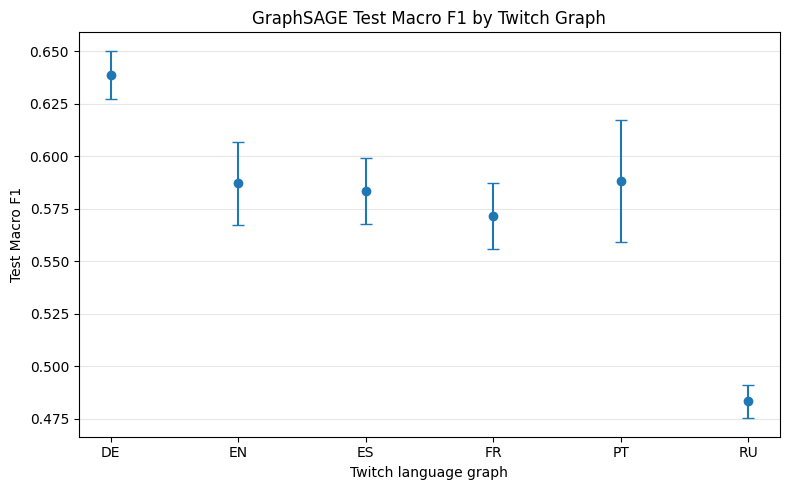

Saved plot to: /content/stat175_graphsage_outputs/plots/graphsage_macro_f1_by_language.png


In [51]:
plot_df = summary_df.sort_values("language")

plt.figure(figsize=(8, 5))
x = np.arange(len(plot_df))
y = plot_df["test_macro_f1_mean"].values
yerr = plot_df["test_macro_f1_std"].fillna(0).values

plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=4)
plt.xticks(x, plot_df["language"].values)
plt.xlabel("Twitch language graph")
plt.ylabel("Test Macro F1")
plt.title("GraphSAGE Test Macro F1 by Twitch Graph")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plot_path = OUTPUT_DIR / "plots" / "graphsage_macro_f1_by_language.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot to:", plot_path)

## 8b. Headline GraphSAGE table for the report

Produce mean ± std test metrics across seeds, both for positive-class F1
(the new shared selection metric across all four notebooks) and for
macro F1 (still useful as a sanity check on imbalanced datasets).
Numbers are pulled from `graphsage_results_raw.csv` so this cell
is safe to re-run without retraining.


In [52]:
# Build a paper-ready GraphSAGE table.
# We report BOTH test_f1 (the headline, matching MLP/GCN/GAT selection metric)
# and test_macro_f1 (more robust on imbalanced classes, useful sanity check).

raw_path = OUTPUT_DIR / "metrics" / "graphsage_results_raw.csv"
df_raw = pd.read_csv(raw_path)

# Keep only the default config (in case the file ever contains other configs).
default_mask = (
    (df_raw["num_layers"] == NUM_LAYERS)
    & (df_raw["hidden_channels"] == HIDDEN_CHANNELS)
    & (df_raw["dropout"] == DROPOUT)
)
df_default = df_raw[default_mask]

headline = (
    df_default
    .groupby("language", as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        test_f1_mean=("test_f1", "mean"),
        test_f1_std=("test_f1", "std"),
        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),
        test_accuracy_mean=("test_accuracy", "mean"),
        test_accuracy_std=("test_accuracy", "std"),
        test_roc_auc_mean=("test_roc_auc", "mean"),
        test_roc_auc_std=("test_roc_auc", "std"),
    )
    .sort_values("language")
    .reset_index(drop=True)
)

# Add an "average across languages" row.
avg_row = {
    "language": "AVG",
    "n_seeds": int(headline["n_seeds"].max()),
}
for col in headline.columns:
    if col in ("language", "n_seeds"):
        continue
    avg_row[col] = headline[col].mean()
headline_with_avg = pd.concat([headline, pd.DataFrame([avg_row])], ignore_index=True)

# Pretty string-formatted version: mean +/- std for each metric.
def _fmt(m, s):
    if pd.isna(s):
        return f"{m:.3f}"
    return f"{m:.3f} ± {s:.3f}"

pretty = pd.DataFrame({
    "language": headline_with_avg["language"],
    "n_seeds": headline_with_avg["n_seeds"],
    "test_f1": [
        _fmt(m, s) for m, s in zip(
            headline_with_avg["test_f1_mean"], headline_with_avg["test_f1_std"]
        )
    ],
    "test_macro_f1": [
        _fmt(m, s) for m, s in zip(
            headline_with_avg["test_macro_f1_mean"], headline_with_avg["test_macro_f1_std"]
        )
    ],
    "test_accuracy": [
        _fmt(m, s) for m, s in zip(
            headline_with_avg["test_accuracy_mean"], headline_with_avg["test_accuracy_std"]
        )
    ],
    "test_roc_auc": [
        _fmt(m, s) for m, s in zip(
            headline_with_avg["test_roc_auc_mean"], headline_with_avg["test_roc_auc_std"]
        )
    ],
})

print("=" * 70)
print("GraphSAGE headline results (default config, mean ± std across seeds)")
print(f"  num_layers={NUM_LAYERS}, hidden_channels={HIDDEN_CHANNELS}, dropout={DROPOUT}")
print(f"  selection_metric={SELECTION_METRIC}")
print("=" * 70)
display(pretty)

headline_path = OUTPUT_DIR / "metrics" / "graphsage_headline_table.csv"
headline_with_avg.to_csv(headline_path, index=False)
print("Saved headline table (raw means/stds) to:", headline_path)

pretty_path = OUTPUT_DIR / "metrics" / "graphsage_headline_table_pretty.csv"
pretty.to_csv(pretty_path, index=False)
print("Saved pretty headline table to:", pretty_path)


GraphSAGE headline results (default config, mean ± std across seeds)
  num_layers=2, hidden_channels=64, dropout=0.5
  selection_metric=macro_f1


,language,n_seeds,test_f1,test_macro_f1,test_accuracy,test_roc_auc
0,DE,5,0.736 ± 0.009,0.639 ± 0.011,0.665 ± 0.011,0.698 ± 0.011
1,EN,5,0.630 ± 0.010,0.587 ± 0.020,0.592 ± 0.017,0.626 ± 0.015
2,ES,5,0.379 ± 0.031,0.583 ± 0.016,0.684 ± 0.012,0.639 ± 0.015
3,FR,5,0.424 ± 0.039,0.572 ± 0.016,0.623 ± 0.012,0.612 ± 0.013
4,PT,5,0.418 ± 0.046,0.588 ± 0.029,0.658 ± 0.022,0.631 ± 0.035
5,RU,5,0.174 ± 0.016,0.483 ± 0.008,0.669 ± 0.015,0.500 ± 0.015
6,AVG,5,0.460 ± 0.025,0.575 ± 0.017,0.649 ± 0.015,0.618 ± 0.017


Saved headline table (raw means/stds) to: /content/stat175_graphsage_outputs/metrics/graphsage_headline_table.csv
Saved pretty headline table to: /content/stat175_graphsage_outputs/metrics/graphsage_headline_table_pretty.csv


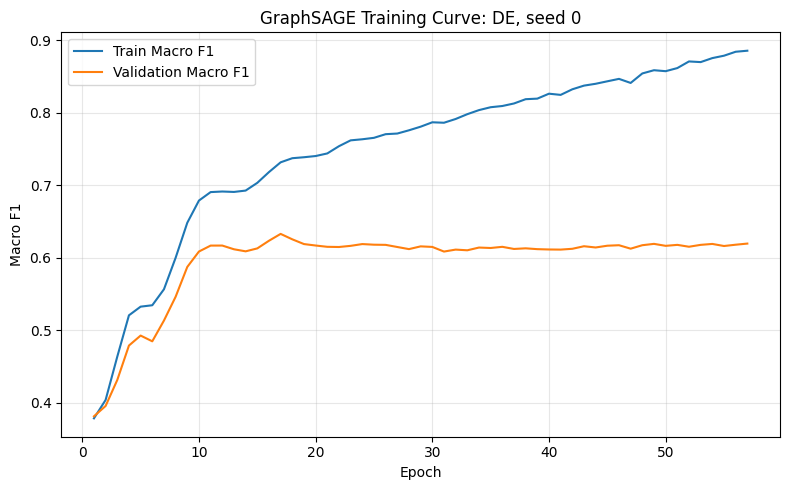

Saved training curve to: /content/stat175_graphsage_outputs/plots/graphsage_training_curve_DE_seed0.png


In [53]:
# Plot one training curve as a sanity check.
if len(all_histories) > 0:
    h = all_histories[0]
    title_language = h["language"].iloc[0]
    title_seed = h["seed"].iloc[0]

    plt.figure(figsize=(8, 5))
    plt.plot(h["epoch"], h["train_macro_f1"], label="Train Macro F1")
    plt.plot(h["epoch"], h["val_macro_f1"], label="Validation Macro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title(f"GraphSAGE Training Curve: {title_language}, seed {title_seed}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    curve_path = OUTPUT_DIR / "plots" / f"graphsage_training_curve_{title_language}_seed{title_seed}.png"
    plt.savefig(curve_path, dpi=200)
    plt.show()

    print("Saved training curve to:", curve_path)

## 9. Optional ablation: number of GraphSAGE layers

Only run this after the main baseline works.

The project plan asks for layer-depth comparisons to check whether deeper GNNs help or whether oversmoothing hurts.

In [57]:
if RUN_LAYER_ABLATION:
    ablation_results = []
    ablation_histories = []

    for num_layers in ABLATION_LAYERS:
        for language in LANGUAGES:
            data = loaded_graphs[language]

            for seed in ABLATION_SEEDS:
                print("=" * 80)
                print(f"Layer ablation: language={language}, seed={seed}, num_layers={num_layers}")

                result, history_df = train_one_graphsage_run(
                    language=language,
                    data=data,
                    seed=seed,
                    hidden_channels=HIDDEN_CHANNELS,
                    num_layers=num_layers,
                    dropout=DROPOUT,
                    lr=LEARNING_RATE,
                    weight_decay=WEIGHT_DECAY,
                    max_epochs=MAX_EPOCHS,
                    patience=PATIENCE,
                    selection_metric=SELECTION_METRIC,
                    verbose=False,
                )

                result["ablation"] = "num_layers"
                ablation_results.append(result)

                hist_path = OUTPUT_DIR / "histories" / f"graphsage_ablation_layers{num_layers}_{language}_seed{seed}.csv"
                history_df.to_csv(hist_path, index=False)

    ablation_df = pd.DataFrame(ablation_results)
    display(ablation_df)

    ablation_raw_path = OUTPUT_DIR / "metrics" / "graphsage_layer_ablation_raw.csv"
    ablation_df.to_csv(ablation_raw_path, index=False)

    ablation_summary_df = (
        ablation_df
        .groupby(["model", "language", "num_layers"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            test_macro_f1_mean=("test_macro_f1", "mean"),
            test_macro_f1_std=("test_macro_f1", "std"),
            test_f1_mean=("test_f1", "mean"),
            test_f1_std=("test_f1", "std"),
            test_accuracy_mean=("test_accuracy", "mean"),
            test_accuracy_std=("test_accuracy", "std"),
        )
    )

    display(ablation_summary_df)

    ablation_summary_path = OUTPUT_DIR / "metrics" / "graphsage_layer_ablation_summary.csv"
    ablation_summary_df.to_csv(ablation_summary_path, index=False)

    print("Saved ablation raw results to:", ablation_raw_path)
    print("Saved ablation summary to:", ablation_summary_path)
else:
    print("RUN_LAYER_ABLATION is False. Set it to True in the configuration cell if you want to run this.")

Layer ablation: language=DE, seed=0, num_layers=1
Layer ablation: language=DE, seed=1, num_layers=1
Layer ablation: language=DE, seed=2, num_layers=1
Layer ablation: language=EN, seed=0, num_layers=1
Layer ablation: language=EN, seed=1, num_layers=1
Layer ablation: language=EN, seed=2, num_layers=1
Layer ablation: language=ES, seed=0, num_layers=1
Layer ablation: language=ES, seed=1, num_layers=1
Layer ablation: language=ES, seed=2, num_layers=1
Layer ablation: language=FR, seed=0, num_layers=1
Layer ablation: language=FR, seed=1, num_layers=1
Layer ablation: language=FR, seed=2, num_layers=1
Layer ablation: language=PT, seed=0, num_layers=1
Layer ablation: language=PT, seed=1, num_layers=1
Layer ablation: language=PT, seed=2, num_layers=1
Layer ablation: language=RU, seed=0, num_layers=1
Layer ablation: language=RU, seed=1, num_layers=1
Layer ablation: language=RU, seed=2, num_layers=1
Layer ablation: language=DE, seed=0, num_layers=2
Layer ablation: language=DE, seed=1, num_layers=2


,model,language,seed,num_layers,hidden_channels,dropout,lr,weight_decay,max_epochs,patience,...,val_accuracy,val_f1,val_macro_f1,val_roc_auc,test_loss,test_accuracy,test_f1,test_macro_f1,test_roc_auc,ablation
0,GraphSAGE,DE,0,1,64,0.5,0.005,0.0005,300,40,...,0.656316,0.730944,0.627671,0.685492,0.635941,0.661053,0.736928,0.630298,0.678949,num_layers
1,GraphSAGE,DE,1,1,64,0.5,0.005,0.0005,300,40,...,0.650526,0.730738,0.616493,0.689609,0.623758,0.654737,0.732899,0.622402,0.693269,num_layers
2,GraphSAGE,DE,2,1,64,0.5,0.005,0.0005,300,40,...,0.669474,0.742834,0.640194,0.708214,0.606415,0.667895,0.744224,0.635428,0.708746,num_layers
3,GraphSAGE,EN,0,1,64,0.5,0.005,0.0005,300,40,...,0.602105,0.643172,0.596764,0.626945,0.672380,0.584853,0.620026,0.581265,0.623824,num_layers
4,GraphSAGE,EN,1,1,64,0.5,0.005,0.0005,300,40,...,0.607719,0.663050,0.596848,0.637554,0.673244,0.579243,0.645390,0.564074,0.613839,num_layers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,GraphSAGE,PT,1,4,64,0.5,0.005,0.0005,300,40,...,0.672775,0.493927,0.626074,0.643061,0.756460,0.673629,0.493927,0.626540,0.675933,num_layers
68,GraphSAGE,PT,2,4,64,0.5,0.005,0.0005,300,40,...,0.714660,0.488263,0.645220,0.668455,0.878475,0.639687,0.349057,0.549980,0.574822,num_layers
69,GraphSAGE,RU,0,4,64,0.5,0.005,0.0005,300,40,...,0.686431,0.216524,0.510258,0.534596,0.886204,0.680730,0.176471,0.489225,0.500450,num_layers
70,GraphSAGE,RU,1,4,64,0.5,0.005,0.0005,300,40,...,0.673888,0.239362,0.515907,0.526291,1.693832,0.660205,0.123529,0.456390,0.498208,num_layers


,model,language,num_layers,n_seeds,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std
0,GraphSAGE,DE,1,3,0.629376,0.006562,0.738017,0.005740,0.661228,0.006581
1,GraphSAGE,DE,2,3,0.638048,0.003138,0.736618,0.001647,0.664912,0.001519
2,GraphSAGE,DE,3,3,0.648297,0.011584,0.732275,0.002921,0.668596,0.005272
3,GraphSAGE,DE,4,3,0.655777,0.008865,0.722504,0.021479,0.669298,0.012414
4,GraphSAGE,EN,1,3,0.580180,0.015591,0.640644,0.018703,0.589528,0.013256
5,GraphSAGE,EN,2,3,0.579603,0.016026,0.626069,0.001197,0.585086,0.012784
6,GraphSAGE,EN,3,3,0.589607,0.012520,0.628130,0.014180,0.593268,0.012797
7,GraphSAGE,EN,4,3,0.589001,0.010029,0.619886,0.034959,0.592567,0.014320
8,GraphSAGE,ES,1,3,0.576714,0.006050,0.339228,0.015497,0.710036,0.005518
9,GraphSAGE,ES,2,3,0.576296,0.015443,0.363442,0.029631,0.683513,0.015594


Saved ablation raw results to: /content/stat175_graphsage_outputs/metrics/graphsage_layer_ablation_raw.csv
Saved ablation summary to: /content/stat175_graphsage_outputs/metrics/graphsage_layer_ablation_summary.csv


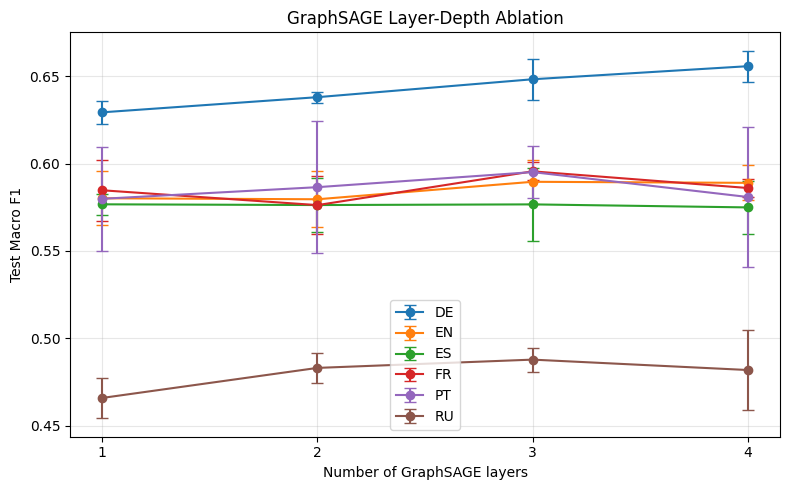

Saved ablation plot to: /content/stat175_graphsage_outputs/plots/graphsage_layer_ablation.png


In [59]:
if RUN_LAYER_ABLATION:
    # Plot layer ablation. One curve per language.
    plt.figure(figsize=(8, 5))

    for language in LANGUAGES:
        sub = ablation_summary_df[ablation_summary_df["language"] == language].sort_values("num_layers")
        plt.errorbar(
            sub["num_layers"],
            sub["test_macro_f1_mean"],
            yerr=sub["test_macro_f1_std"].fillna(0),
            marker="o",
            capsize=4,
            label=language,
        )

    plt.xlabel("Number of GraphSAGE layers")
    plt.ylabel("Test Macro F1")
    plt.title("GraphSAGE Layer-Depth Ablation")
    plt.xticks(ABLATION_LAYERS)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    ablation_plot_path = OUTPUT_DIR / "plots" / "graphsage_layer_ablation.png"
    plt.savefig(ablation_plot_path, dpi=200)
    plt.show()

    print("Saved ablation plot to:", ablation_plot_path)

## 10. Create a zip file of outputs

Use this at the end to download all CSVs and plots.

In [58]:
# Zip outputs for download.
zip_path = "/content/graphsage_outputs.zip"
!zip -r -q {zip_path} {OUTPUT_DIR}
print("Created:", zip_path)

# In Colab, uncomment this to download the zip directly.
from google.colab import files
files.download(zip_path)

Created: /content/graphsage_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Short write-up notes for the final report

You can adapt this language after the full results are available:

> We implemented GraphSAGE as a strong message-passing baseline for binary node classification on the Twitch gamer networks. Unlike the MLP baseline, GraphSAGE uses graph structure by aggregating information from neighboring nodes. For each language graph, we used stratified 60/20/20 train/validation/test splits and repeated training across random seeds. We selected the best epoch using validation macro F1 and reported test accuracy, F1, macro F1, and ROC-AUC. This baseline lets us compare attention-based aggregation in GAT against a non-attention neighborhood aggregation method.

If GraphSAGE performs similarly to or better than GAT, the interpretation is not that the project failed. It may mean that learned attention was unnecessary on some Twitch graphs, or that simpler aggregation was easier to optimize.